# Bancada de Testes: Pipeline Experimental de Processamento de Imagens

Este notebook serve como bancada didática e experimental para:
1. Testar o processamento de imagens brutas da **Câmera Fixa** (1920x1080 com 2 boxes) e **Fotos Históricas de Celular**.
2. Visualizar cada etapa de transformação: corte (crop), rotação, máscara de paredes (ROI), denoise, CLAHE, gamma e nitidez.
3. Comparar **variantes de filtros** lado a lado.
4. Avaliar **métricas de qualidade da imagem** (brilho, contraste, nitidez, entropia, ruído).
5. Testar o resize final para (224, 224) antes do envio ao YOLO.

> **Dica para desenvolvedores Pascal/C#:** Cada célula executa um bloco sequencial claro. Você pode alterar parâmetros numéricos diretamente nas variáveis e rodar a célula (Shift + Enter).

In [8]:
# 1. IMPORTS E CONFIGURAÇÃO DO AMBIENTE
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Adiciona o diretório 'pipeline_final' ao sys.path para importar o pacote image_processing
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'pipeline_final'))
print(BASE_DIR)
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from image_processing import (
    carregar_imagem,
    validar_imagem,
    dividir_imagem_pipeline_final,
    aplicar_espelhamento,
    aplicar_rotacao,
    aplicar_mascara_roi,
    redimensionar_com_letterbox,
    converter_para_escala_cinza,
    aplicar_clahe,
    calcular_metricas_qualidade,
    processar_box,
    processar_imagem_pipeline_final,
    ConfiguracaoPipeline,
    ConfiguracaoTransformacaoBox,
    PONTO_DIVISAO_X_PADRAO,
    TAMANHO_IMAGEM_DESTINO
)

# Funções utilitárias de visualização (OpenCV BGR -> Matplotlib RGB)
def show_image(img, title='Imagem', figsize=(8, 6)):
    plt.figure(figsize=figsize)
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

def show_side_by_side(images, titles, figsize=(16, 6)):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        if img.ndim == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=11)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('Ambiente e módulos importados com sucesso!')

d:\Dev\Projetos\Python\fertilizantes\producao
Ambiente e módulos importados com sucesso!


d:\Dev\Projetos\Python\fertilizantes\data\camerafixa\2026_08_21-2026_08_21\172.19.65.208_01_20260821084906577_TIMING.jpg


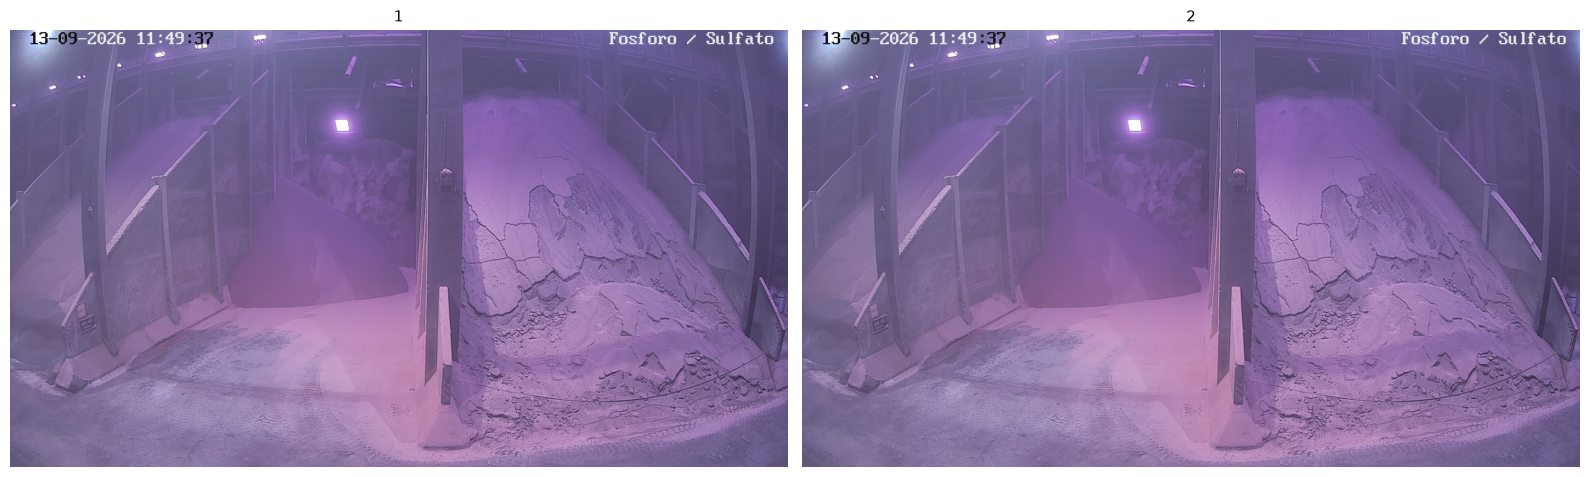

In [10]:
print(os.path.abspath(os.path.join(BASE_DIR, '..', 'data', 'camerafixa', '2026_08_21-2026_08_21', '172.19.65.208_01_20260821084906577_TIMING.jpg')))
IMG_PATH_CAMERA_FIXA1 = carregar_imagem(os.path.abspath(os.path.join(BASE_DIR, '..', 'data', 'camerafixa', '2026_09_13-2026_09_13', '172.19.65.208_01_20260913114937368_TIMING.jpg')))
IMG_PATH_CAMERA_FIXA2 = carregar_imagem(os.path.abspath(os.path.join(BASE_DIR, '..', 'data', 'camerafixa', '2026_09_13-2026_09_13', '172.19.65.208_01_20260913114937368_TIMING.jpg')))
# IMG_PATH_CAMERA_FIXA1 = carregar_imagem(r'\\zeta\IA_Fertilizantes\2026_09_13-2026_09_13\172.19.65.208_01_20260913114937368_TIMING.jpg')
# IMG_PATH_CAMERA_FIXA2 = carregar_imagem(r'\\zeta\IA_Fertilizantes\2026_09_13-2026_09_13\172.19.65.208_01_20260913114937368_TIMING.jpg')
show_side_by_side([IMG_PATH_CAMERA_FIXA1, IMG_PATH_CAMERA_FIXA2], ['1', '2'])

Imagem Carregada: 1920x1080 pixels, 3 canais.


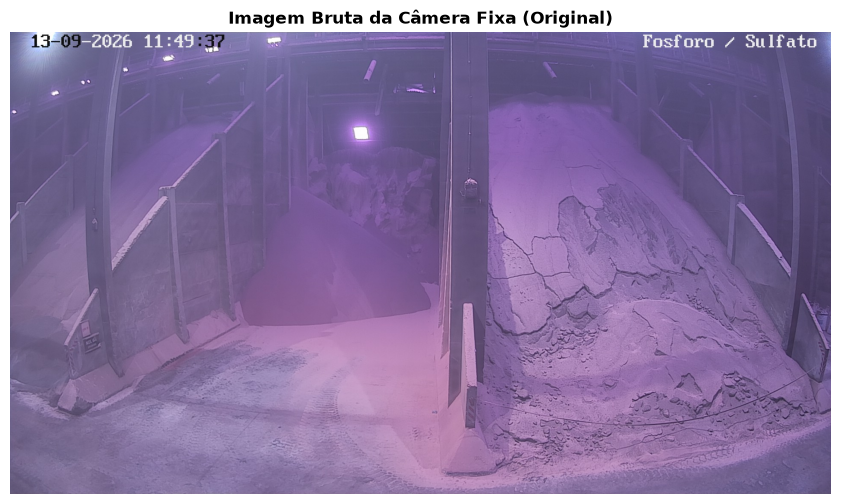

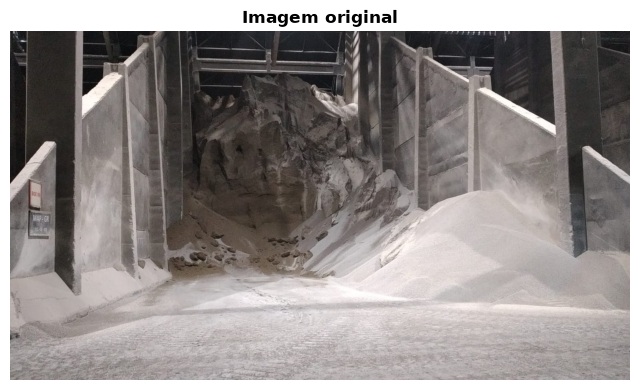

In [12]:
# 2. SELEÇÃO DA IMAGEM DE TESTE
# Altere os caminhos abaixo conforme desejado:

# Imagem da câmera fixa (1920x1080 com 2 boxes)
IMG_PATH_CAMERA_FIXA = os.path.abspath(os.path.join(BASE_DIR, '..', 'data', 'camerafixa', '2026_09_13-2026_09_13', '172.19.65.208_01_20260913114937368_TIMING.jpg'))
# IMG_PATH_CAMERA_FIXA = os.path.abspath(os.path.join(BASE_DIR, '..', 'data', 'camerafixa', '2026_08_30-2026_08_30', '172.19.65.208_01_20260830114920035_TIMING.jpg'))

# Foto histórica de celular (box individual)
IMG_PATH_HISTORICA = os.path.abspath(os.path.join(BASE_DIR, '..', 'data', 'originais', '71to80', '29.08.2025_BOX9_76%.jpg'))
# D:\Dev\Projetos\Python\fertilizantes\data\originais\71to80\29.08.2025_BOX9_76%.jpg
img_raw = carregar_imagem(IMG_PATH_CAMERA_FIXA)
imagem_hist = carregar_imagem(IMG_PATH_HISTORICA)
print(f'Imagem Carregada: {img_raw.shape[1]}x{img_raw.shape[0]} pixels, {img_raw.shape[2]} canais.')
show_image(img_raw, title='Imagem Bruta da Câmera Fixa (Original)', figsize=(12, 6))
show_image(imagem_hist, 'Imagem original')

In [2]:
def count_images(train_dir):
    # Criar uma lista vazia para armazenar os nomes das pastas
    pastas = []
    extensoes = ('.jpg', '.jpeg', '.png', '.bmp')
    lista = sorted(os.listdir(train_dir))
    for d in lista:
        # Criamos o caminho completo para verificar se é diretório
        caminho_completo = os.path.join(train_dir, d)
        
        # Se for uma pasta, adicionamos à nossa lista
        if os.path.isdir(caminho_completo):
            pastas.append(d)

    # 2. Criar um dicionário vazio para as contagens
    contagens = {}
    for pasta in pastas:
        # Montamos o caminho da subpasta
        caminho_subpasta = os.path.join(train_dir, pasta)
        
        # Listamos os arquivos dentro dela
        arquivos_na_pasta = [f for f in os.listdir(caminho_subpasta) if f.lower().endswith(extensoes)]
        
        # Guardamos o nome da pasta como CHAVE e a quantidade como VALOR
        contagens[pasta] = len(arquivos_na_pasta)

    max_imagens = max(contagens.values())

    for classe, quantidade in contagens.items():
        print(f'Classe: {classe}, Quantidade: {quantidade}')
    
    total = sum(contagens.values())
    print(f'Total de imagens: {total}')
    return contagens, max_imagens

In [6]:
count_images(r'D:\Dev\Projetos\Python\fertilizantes\data\originais')
count_images(r'D:\Dev\Projetos\Python\fertilizantes\data\originais_sugeira')

Classe: 0to10, Quantidade: 55
Classe: 11to20, Quantidade: 29
Classe: 21to30, Quantidade: 33
Classe: 31to40, Quantidade: 37
Classe: 41to50, Quantidade: 74
Classe: 51to60, Quantidade: 45
Classe: 61to70, Quantidade: 61
Classe: 71to80, Quantidade: 57
Classe: 81to90, Quantidade: 91
Classe: 91to100, Quantidade: 253
Total de imagens: 735
Classe: 0to10, Quantidade: 6
Classe: 11to20, Quantidade: 15
Classe: 21to30, Quantidade: 11
Classe: 31to40, Quantidade: 11
Classe: 41to50, Quantidade: 16
Classe: 51to60, Quantidade: 13
Classe: 61to70, Quantidade: 11
Classe: 71to80, Quantidade: 8
Classe: 81to90, Quantidade: 24
Classe: 91to100, Quantidade: 29
Total de imagens: 144


({'0to10': 6,
  '11to20': 15,
  '21to30': 11,
  '31to40': 11,
  '41to50': 16,
  '51to60': 13,
  '61to70': 11,
  '71to80': 8,
  '81to90': 24,
  '91to100': 29},
 29)

Box Esquerdo: 1050x1080 px | Box Direito: 870x1080 px


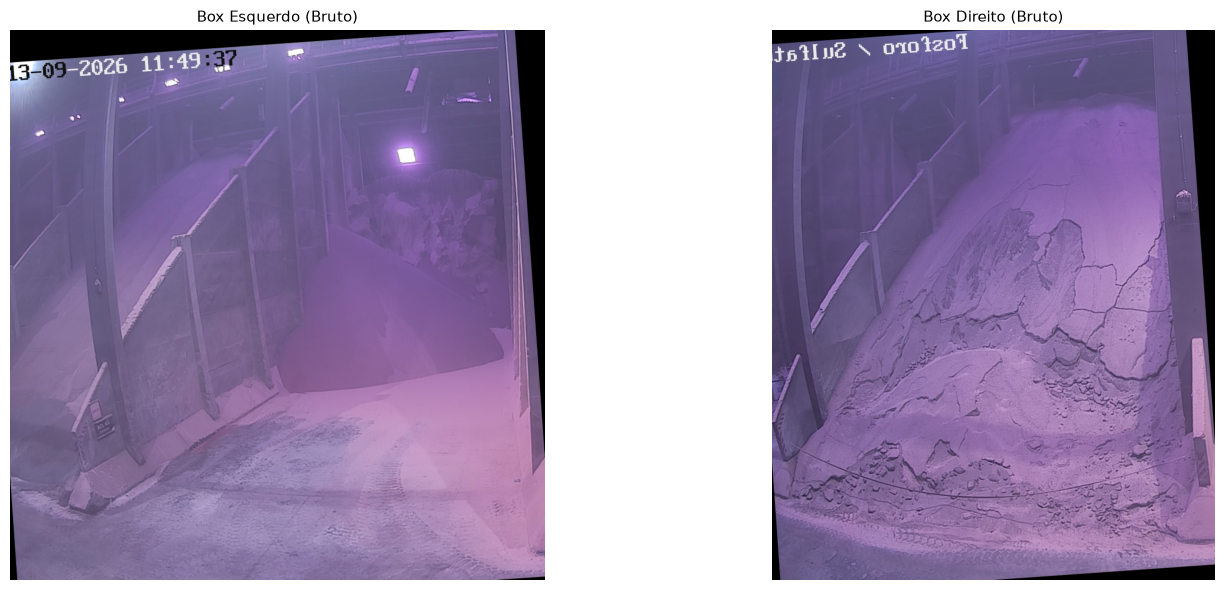

In [15]:
# 3. SEPARAÇÃO DOS BOXES (ESQUERDO E DIREITO)
SPLIT_X = 1050

left_raw, right_raw = dividir_imagem_pipeline_final(imagem=img_raw, ponto_divisao_x=SPLIT_X)
left_raw = aplicar_rotacao(imagem=left_raw, angulo=4, deslocamento_x=-20, deslocamento_y=30, valor_preenchimento=0)
right_raw = aplicar_rotacao(imagem=cv2.flip(right_raw, 1), angulo=4, deslocamento_x=-20, deslocamento_y=0, valor_preenchimento=0)

print(f'Box Esquerdo: {left_raw.shape[1]}x{left_raw.shape[0]} px | Box Direito: {right_raw.shape[1]}x{right_raw.shape[0]} px')

show_side_by_side([left_raw, right_raw], ['Box Esquerdo (Bruto)', 'Box Direito (Bruto)'])

In [6]:
import cv2
import numpy as np

# =========================================================
# CONFIGURAÇÃO
# =========================================================

# Troque conforme necessário
PARAM_NAME = "ROI_POLYGON_LEFT"

# Imagem de entrada
image = left_raw.copy()
# image = right_raw.copy()

# Escala da janela de visualização
DISPLAY_SCALE = 0.50   # teste 0.40 se ainda ficar grande

# Cor/valor fora da ROI
MASK_FILL_VALUE = 0    # 0 = preto

# Tolerância para clicar nos pontos
CLICK_TOLERANCE_DISPLAY_PX = 30

# =========================================================
# ROI INICIAL (EXEMPLO COM 6 PONTOS)
# Você pode colocar 4, 5, 6, 8... quantos quiser
# Ordem: sentido horário ou anti-horário, mas consistente
# =========================================================
points = np.array([
    [300, 20],                    # P1
    [800, 20],                    # P2
    [800, 800],                  # P3
    [180, 800],                  # P4
    [110, 760],                   # P5
    [170, 420],                   # P6
    [180, 520],                   # P6
    [180, 520],                   # P6
    [180, 520],                   # P6
], dtype=np.float32)

initial_points = points.copy()

labels = [f"P{i+1}" for i in range(len(points))]
selected_point = None

display_width = int(image.shape[1] * DISPLAY_SCALE)
display_height = int(image.shape[0] * DISPLAY_SCALE)


# =========================================================
# FUNÇÕES AUXILIARES
# =========================================================

def apply_roi_preview(img, roi_points, mask_fill_value=0):
    """
    Aplica uma máscara poligonal na imagem.
    """
    h, w = img.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)
    pts_array = np.array([roi_points.astype(np.int32)], dtype=np.int32)
    cv2.fillPoly(mask, pts_array, 255)

    if img.ndim == 3:
        masked = np.full_like(img, mask_fill_value)
        masked[mask == 255] = img[mask == 255]
    else:
        masked = np.full_like(img, mask_fill_value)
        masked[mask == 255] = img[mask == 255]

    return masked


def build_overlay_preview(img, roi_points):
    """
    Cria uma visualização com a área fora da ROI escurecida,
    o que costuma facilitar o ajuste visual.
    """
    h, w = img.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)
    pts_array = np.array([roi_points.astype(np.int32)], dtype=np.int32)
    cv2.fillPoly(mask, pts_array, 255)

    overlay = img.copy()

    # escurece fora da ROI
    darkened = (overlay * 0.25).astype(np.uint8)
    overlay[mask == 0] = darkened[mask == 0]

    # destaca contorno
    cv2.polylines(
        overlay,
        [roi_points.astype(np.int32)],
        isClosed=True,
        color=(0, 255, 0),
        thickness=3
    )

    return overlay


def print_roi_points():
    print(f"\n{PARAM_NAME} = [")
    for x, y in points.astype(int):
        print(f"    ({x}, {y}),")
    print("]")


# =========================================================
# CALLBACK DO MOUSE
# =========================================================

def mouse_callback(event, x, y, flags, param):
    global selected_point, points

    original_x = x / DISPLAY_SCALE
    original_y = y / DISPLAY_SCALE
    mouse_position = np.array([original_x, original_y], dtype=np.float32)

    if event == cv2.EVENT_LBUTTONDOWN:
        distances = np.linalg.norm(points - mouse_position, axis=1)
        idx = np.argmin(distances)

        tolerance = CLICK_TOLERANCE_DISPLAY_PX / DISPLAY_SCALE
        if distances[idx] < tolerance:
            selected_point = idx

    elif event == cv2.EVENT_MOUSEMOVE:
        if selected_point is not None:
            original_x = np.clip(original_x, 0, image.shape[1] - 1)
            original_y = np.clip(original_y, 0, image.shape[0] - 1)
            points[selected_point] = [original_x, original_y]

    elif event == cv2.EVENT_LBUTTONUP:
        selected_point = None


# =========================================================
# JANELAS
# =========================================================

cv2.namedWindow("Original + ROI", cv2.WINDOW_NORMAL)
cv2.namedWindow("ROI Masked", cv2.WINDOW_NORMAL)
cv2.namedWindow("ROI Overlay", cv2.WINDOW_NORMAL)

cv2.setMouseCallback("Original + ROI", mouse_callback)


# =========================================================
# LOOP PRINCIPAL
# =========================================================

while True:
    display = image.copy()
    pts_int = points.astype(np.int32)

    # desenha polígono
    cv2.polylines(
        display,
        [pts_int],
        isClosed=True,
        color=(0, 255, 0),
        thickness=3
    )

    # desenha pontos e labels
    for i, (px, py) in enumerate(pts_int):
        cv2.circle(display, (px, py), 10, (0, 0, 255), -1)
        cv2.putText(
            display,
            labels[i],
            (px + 12, py - 12),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 255),
            2
        )

    # previews
    masked = apply_roi_preview(image, points, mask_fill_value=MASK_FILL_VALUE)
    overlay = build_overlay_preview(image, points)

    # resize só para exibição
    display_small = cv2.resize(display, (display_width, display_height), interpolation=cv2.INTER_AREA)
    masked_small = cv2.resize(masked, (display_width, display_height), interpolation=cv2.INTER_AREA)
    overlay_small = cv2.resize(overlay, (display_width, display_height), interpolation=cv2.INTER_AREA)

    cv2.imshow("Original + ROI", display_small)
    cv2.imshow("ROI Masked", masked_small)
    cv2.imshow("ROI Overlay", overlay_small)

    key = cv2.waitKey(20) & 0xFF

    # ESC = sair
    if key == 27:
        break

    # S = imprimir ROI
    elif key == ord("s"):
        print_roi_points()

    # R = resetar pontos
    elif key == ord("r"):
        points = initial_points.copy()

cv2.destroyAllWindows()

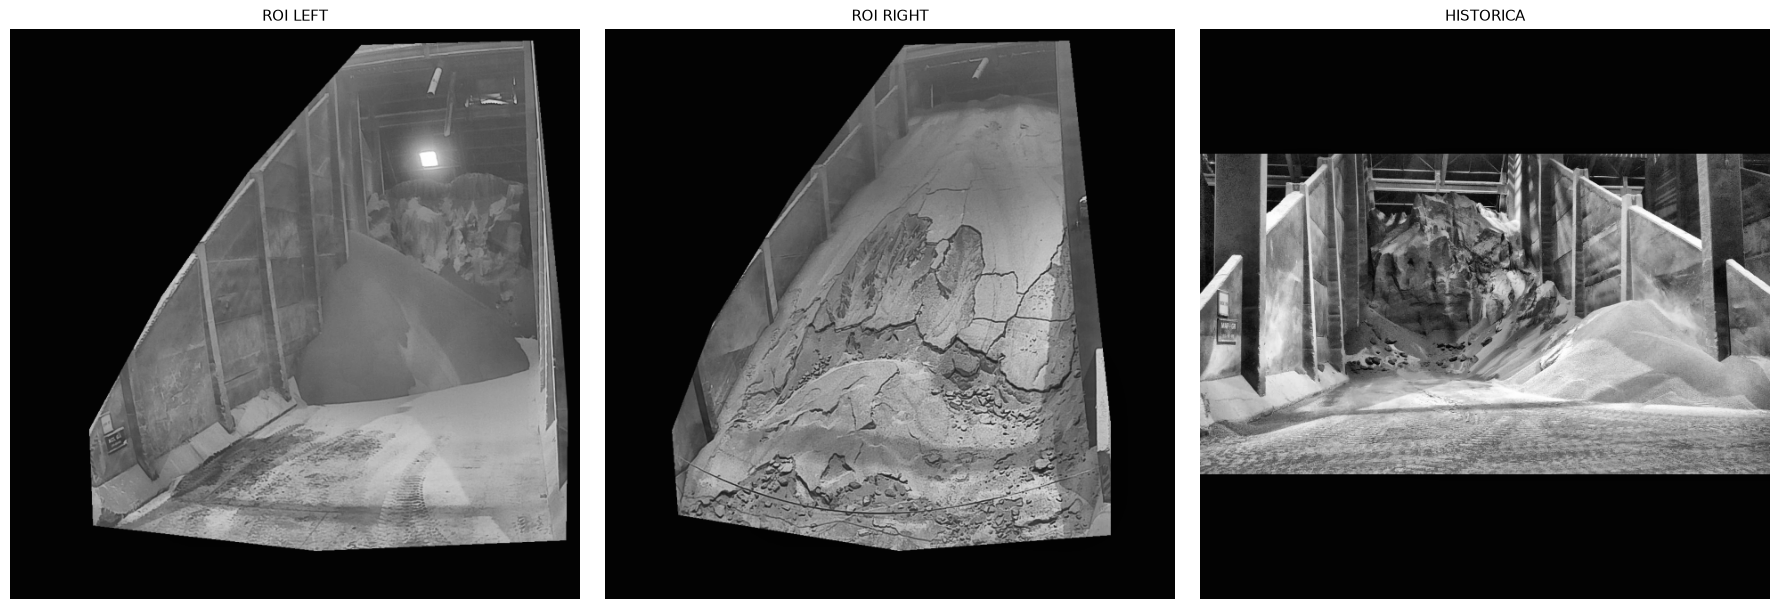

{'brilho': 67.23,
 'contraste': 66.4,
 'nitidez': 913.53,
 'entropia': 4.86,
 'razao_pixels_escuros': 0.4758,
 'razao_pixels_claros': 0.0,
 'status': 'BAIXA_LUMINOSIDADE',
 'alertas': ['BAIXA_LUMINOSIDADE']}

In [16]:
ROI_POLYGON_LEFT = [
    (650, 30), #1
    (976, 22), #2
    (1042, 684), #3
    (1038, 968), #4
    (564, 988),#5
    (142, 940),#6
    (135, 758),#7
    (272, 506),#8
    (435, 272),#9
]

ROI_POLYGON_RIGHT = [
    (462, 30), #1
    (774, 22), #2
    (852, 746),#3
    (852, 958),#4
    (452, 988),#5
    (34, 920),#6
    (22, 760),#7
    (100, 556),#8
    (256, 302),#9
]

box_roi_left = aplicar_mascara_roi(left_raw, ROI_POLYGON_LEFT)
box_roi_left = redimensionar_com_letterbox(box_roi_left, (640, 640))
box_roi_left = aplicar_clahe(converter_para_escala_cinza(box_roi_left, True), limite_contraste=2.0, tamanho_grade=(8, 8))

box_roi_right = aplicar_mascara_roi(right_raw, ROI_POLYGON_RIGHT)
box_roi_right = redimensionar_com_letterbox(box_roi_right, (640, 640))
box_roi_right = aplicar_clahe(converter_para_escala_cinza(box_roi_right, True), limite_contraste=2.0, tamanho_grade=(8, 8))

imagem_hist = redimensionar_com_letterbox(imagem_hist, (640, 640))
imagem_hist = aplicar_clahe(converter_para_escala_cinza(imagem_hist, True), limite_contraste=2.0, tamanho_grade=(8, 8))


show_side_by_side(
    [box_roi_left, box_roi_right, imagem_hist],
    ['ROI LEFT', 'ROI RIGHT', 'HISTORICA'],
    figsize=(18, 6)
)


calcular_metricas_qualidade(box_roi_left)
calcular_metricas_qualidade(box_roi_right)

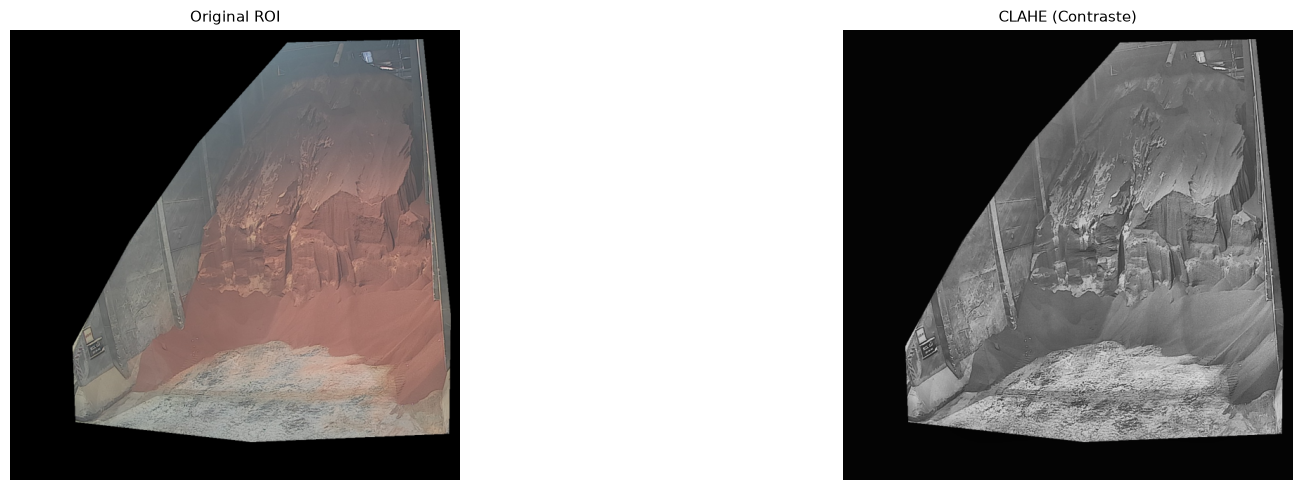

In [14]:
# 5. TESTANDO FILTROS INDIVIDUAIS (ENHANCEMENT)
# Inspecione o efeito isolado de cada técnica sobre a imagem:
box_roi = box_roi_left
# box_roi = box_roi_right
# box_roi = 

# Denoise Bilateral: suaviza ruído sem borrar as bordas do fertilizante
# img_denoised = apply_denoise(box_roi, method='bilateral', bilateral_d=5, bilateral_sigma_color=50.0)

# CLAHE: realce adaptativo de contraste local (opera no canal Luminância do espaço LAB)
img_gray = apply_grayscale(box_roi, keep_3_channels=True)
img_clahe = apply_clahe(img_gray, clip_limit=2.0, tile_grid_size=(8, 8))


# Gamma: clareia sombras (< 1.0) ou escurece (> 1.0)
# img_gamma = apply_gamma(box_roi, gamma=0.8)

# Sharpen: aumento suave de nitidez das bordas
# img_sharpen = apply_sharpen(box_roi, strength=0.5)

# Grayscale: conversão para escala de cinza
# img_gray = apply_grayscale(box_roi, keep_3_channels=True)

# show_side_by_side(
#     [box_roi, img_clahe, img_gamma, img_denoised, img_gray],
#     ['Original ROI', 'CLAHE (Contraste)', 'Gamma 0.8 (Luz)', 'Denoise Bilateral', 'Grayscale'],
#     figsize=(20, 5)
# )
show_side_by_side(
    [box_roi, img_clahe],
    ['Original ROI', 'CLAHE (Contraste)'],
    figsize=(20, 5)
)

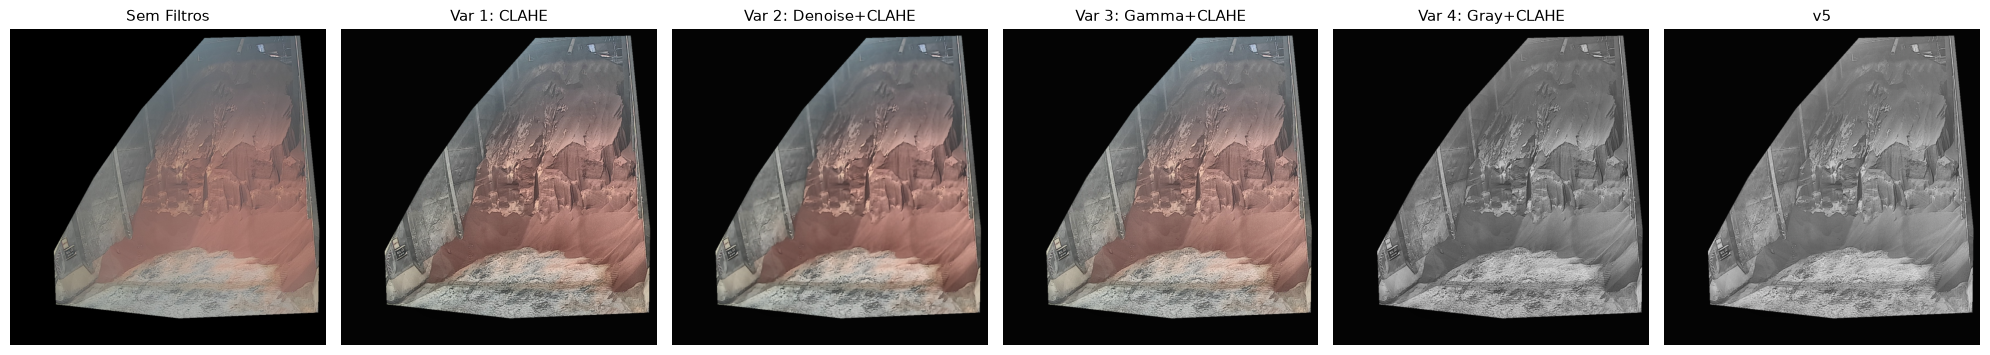

In [19]:
# 6. COMPARAÇÃO DE VARIANTES DE PIPELINE
# Experimente combinações de filtros para comparar qual preserva melhor as características da pilha:
tile_grid=(8, 8)

v1 = apply_clahe(box_roi, clip_limit=2.0, tile_grid_size=tile_grid)
v2 = apply_clahe(apply_denoise(box_roi, method='bilateral'), clip_limit=2.0, tile_grid_size=tile_grid)
v3 = apply_clahe(apply_gamma(box_roi, gamma=0.85), clip_limit=2.0, tile_grid_size=tile_grid)
v4 = apply_clahe(apply_grayscale(box_roi, keep_3_channels=True), clip_limit=2.0, tile_grid_size=tile_grid)
v5 = apply_clahe(apply_gamma(apply_grayscale(box_roi, keep_3_channels=True), gamma=0.85), clip_limit=2.0, tile_grid_size=tile_grid)


show_side_by_side(
    [box_roi, v1, v2, v3, v4, v5],
    ['Sem Filtros', 'Var 1: CLAHE', 'Var 2: Denoise+CLAHE', 'Var 3: Gamma+CLAHE', 'Var 4: Gray+CLAHE', 'v5'],
    figsize=(20, 5)
)

In [ ]:
# 7. CÁLCULO DE MÉTRICAS DE QUALIDADE DE IMAGEM
# Calcula brilho médio, contraste, nitidez (variância laplaciana), entropia e taxas de pixels extremos

print('=== MÉTRICAS DA IMAGEM SEM TRATAMENTO ===')
m_raw = calcular_metricas_qualidade(box_roi)
for k, v in m_raw.items():
    print(f'  {k:22s}: {v}')

print('\n=== MÉTRICAS APÓS TRATAMENTO (VARIANTE 1: CLAHE) ===')
m_enh = calcular_metricas_qualidade(v1)
for k, v in m_enh.items():
    print(f'  {k:22s}: {v}')
    
print('\n=== MÉTRICAS APÓS TRATAMENTO (VARIANTE 2: Denoise + CLAHE) ===')
m_enh = calcular_metricas_qualidade(v2)
for k, v in m_enh.items():
    print(f'  {k:22s}: {v}')
    
print('\n=== MÉTRICAS APÓS TRATAMENTO (VARIANTE 3: Gamma + CLAHE) ===')
m_enh = calcular_metricas_qualidade(v3)
for k, v in m_enh.items():
    print(f'  {k:22s}: {v}')
    

print('\n=== MÉTRICAS APÓS TRATAMENTO (VARIANTE 4: Gray + CLAHE) ===')
m_enh = calcular_metricas_qualidade(v4)
for k, v in m_enh.items():
    print(f'  {k:22s}: {v}')

=== MÉTRICAS DA IMAGEM SEM TRATAMENTO ===
  brightness            : 72.04
  contrast              : 64.24
  sharpness             : 452.59
  entropy               : 4.62
  dark_pixel_ratio      : 0.4266
  bright_pixel_ratio    : 0.0
  status                : LOW_LIGHT
  warnings              : ['LOW_LIGHT']

=== MÉTRICAS APÓS TRATAMENTO (VARIANTE 1: CLAHE) ===
  brightness            : 72.92
  contrast              : 64.25
  sharpness             : 1655.45
  entropy               : 5.04
  dark_pixel_ratio      : 0.4265
  bright_pixel_ratio    : 0.0
  status                : LOW_LIGHT
  warnings              : ['LOW_LIGHT']

=== MÉTRICAS APÓS TRATAMENTO (VARIANTE 2: Denoise + CLAHE) ===
  brightness            : 73.35
  contrast              : 63.97
  sharpness             : 711.17
  entropy               : 4.99
  dark_pixel_ratio      : 0.4267
  bright_pixel_ratio    : 0.0
  status                : LOW_LIGHT
  warnings              : ['LOW_LIGHT']

=== MÉTRICAS APÓS TRATAMENTO (VARIANT

{'00_extracted': array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(1080, 1050, 3), dtype=uint8), '03_roi': array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
 

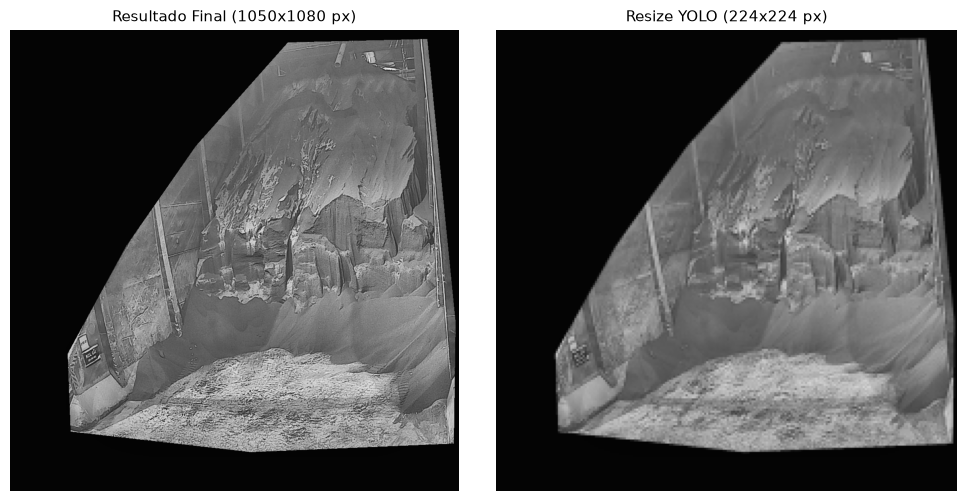

In [24]:
# 8. TESTE DO PIPELINE COMPLETO ATRAVÉS DO OBJETO DE CONFIGURAÇÃO (ProcessingConfig)
# Configuração centralizada para fácil reprodução e manutenção

config = ProcessingConfig()

# Geometria do Box Esquerdo
# config.production.left_box.crop_box = CROP_BOX_LEFT
# config.production.left_box.rotation_angle = ROTATION_ANGLE_LEFT
config.production.left_box.roi_polygon = ROI_POLYGON_LEFT
config.production.right_box.roi_polygon = ROI_POLYGON_RIGHT

# Filtros Comuns Ativados
config.common.denoise.enabled = False
config.common.denoise.method = 'bilateral'
config.common.clahe.enabled = True
config.common.clahe.clip_limit = 2.0
config.common.grayscale = True

# Executa o pipeline
final_box, steps = preprocess_production_box(left_raw, side='left', config=config, return_steps=True)
print(steps)
# Redimensionamento final para (224, 224) para o modelo YOLO
final_224 = resize_to_target_size(final_box, target_size=(224, 224))

show_side_by_side(
    [final_box, final_224],
    [f'Resultado Final ({final_box.shape[1]}x{final_box.shape[0]} px)', f'Resize YOLO ({final_224.shape[1]}x{final_224.shape[0]} px)'],
    figsize=(10, 5)
)

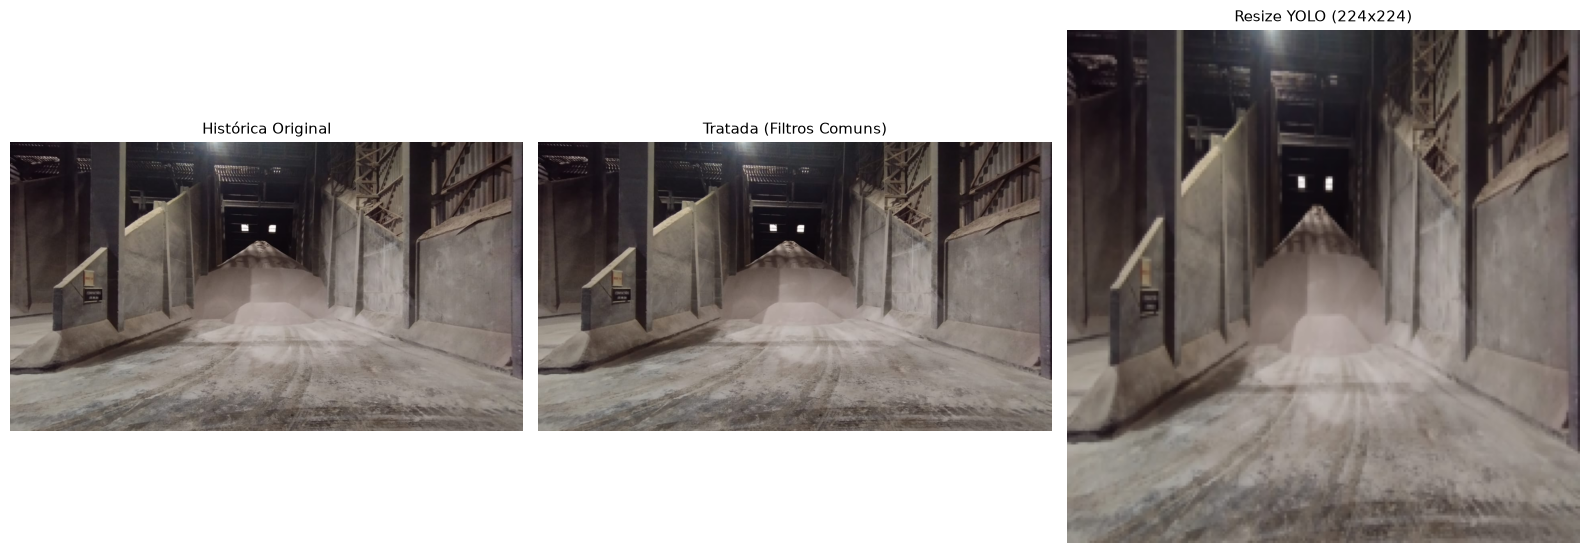

In [11]:
# 9. PROCESSAMENTO DE FOTO HISTÓRICA DE CELULAR
# Processa foto antiga aplicando APENAS os filtros comuns, sem aplicar geometria de câmera fixa

if os.path.exists(IMG_PATH_HISTORICA):
    img_hist = load_image(IMG_PATH_HISTORICA)
    processed_hist = preprocess_historical_image(img_hist, config=config)
    hist_224 = resize_to_target_size(processed_hist, target_size=(224, 224))
    
    show_side_by_side(
        [img_hist, processed_hist, hist_224],
        ['Histórica Original', 'Tratada (Filtros Comuns)', 'Resize YOLO (224x224)']
    )
else:
    print(f'Arquivo não encontrado: {IMG_PATH_HISTORICA}')